# Lab 065 · Extract embeddings without their own labels

[Lesson](../lessons/0065-tabpfn-query-embeddings.html) · [Reference](../reference/0065-tabpfn-query-embeddings.html) · [Reproduction contract](l065-reproduction.md)

**Route:** retrieve → explain → predict → implement → CHECK → inspect evidence → EXIT. PROVIDED cells are readable implementation and peripheral support. TODOs contain your load-bearing code; CHECKs give immediate diagnostic feedback. Complete the code before revealing teacher solutions. Core study: 35–50 minutes; lab: 45–75 minutes plus explicitly gated larger runs.

**Before reading:** Can you treat a labeled-context embedding as an equivalent unlabeled-query embedding? Write your answer and justify the information boundary. Then recall one older lesson that could expose an error in this experiment.

**Evidence contract:** numerical figures labeled author-reference come from committed author measurements. They are not outputs of your current kernel. Reduced model mechanisms, pretrained reference inference, frozen-result reanalysis and paper reproduction are different tracks. Every track states its scope below.

### Running on Google Colab?

Colab opens only this single file, so the course package (`relkit`) and the lab
dependencies (xgboost, lightgbm, catboost, …) are **not** present by default. The cell
below fixes that: on Colab it shallow-clones the course repo, installs
`requirements-labs.txt`, and switches into `labs/` so `relkit` imports and the data cache
resolve. **On a local venv or your own Jupyter it does nothing — just run it and continue.**

In [ ]:
# @colab-bootstrap — PROVIDED. Makes the lab self-sufficient on Google Colab; a no-op elsewhere.
import os, sys

if "google.colab" in sys.modules:
    if not os.path.isdir("/content/relational"):
        !git clone --depth 1 https://github.com/Avistian/relational.git /content/relational
    %pip install -q -r /content/relational/requirements-labs.txt
    os.chdir("/content/relational/labs")
    print("Colab ready — working dir:", os.getcwd())
else:
    print("Not on Colab — using the local environment as-is.")

## A useful representation can still have the wrong information

Your goal is to extract representations that give a downstream classifier a fair training problem. Read [Ye et al., Section 6](https://arxiv.org/html/2502.17361v1#S6). The paper distinguishes a labeled **support/context** row from an unlabeled **query** row. Their feature values can be identical while their representations differ, because one receives its known label as input.

This matters for heterogeneous tables: an encoder can transform different feature types and distributions into a common hidden space. But a visually separable embedding plot does not prove that a new, unlabeled row will be separable in the same way. If training embeddings already contain their own labels, a linear classifier may learn to read a channel that disappears at inference. This is an information-role mismatch, not merely a scaling problem.

## Trace the label route

Imagine two rows with identical feature vector x and opposite labels. A context representation of the form `encode(x)+label_embedding(y)` can distinguish them perfectly. At prediction time, both rows have unknown targets, so that direct label difference is absent. A scatter plot of context embeddings may therefore look impressive for a reason unavailable to the deployed predictor.

The appropriate counterfactual is to remove a row's label while extracting that row's representation. In the reduced PFN, the embedding function receives labeled context and separate query features. It has no query-target argument. In the official v2 API, use the query/test representation route and inspect the exact package version; `get_embeddings(..., data_source='train')` and `data_source='test'` describe different information roles.

<div style="overflow-x:auto;max-width:100%">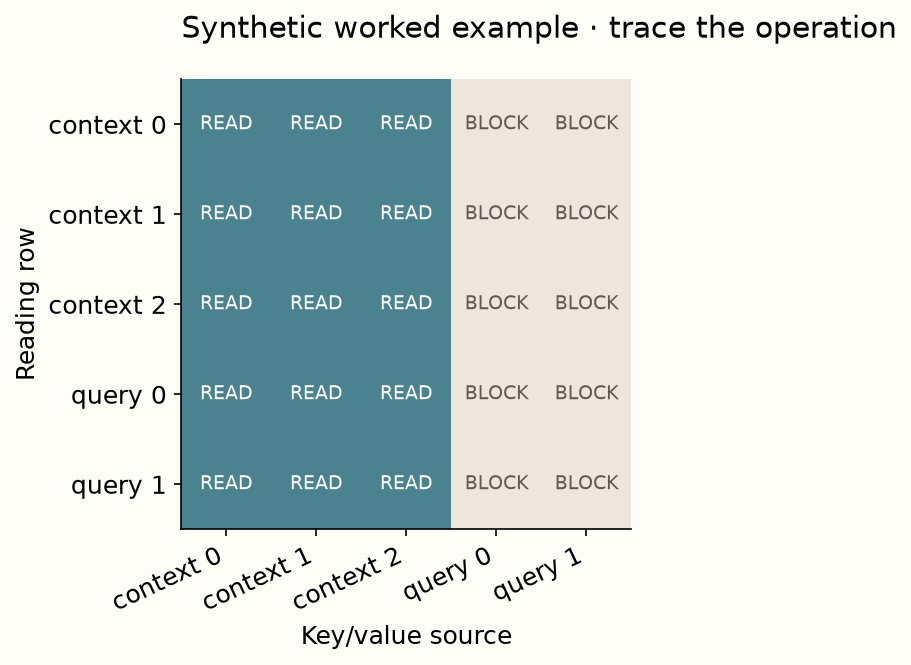</div>

*L065 mechanism: worked computation; see adjacent explanation. Scroll wide figures horizontally on small screens.*

## Cross-fit the representation

Partition the outer training rows into K folds. For each fold, use the other K−1 folds as labeled context and extract the held-out fold as unlabeled queries. Scatter the representations back into their original row order. Every training row receives one query-role vector. Fit the downstream head on those vectors and the ordinary training targets. Labels can train the head; they must not have entered each row's own extracted representation.

For rows `[0,1,2,3]` with folds `[0,1,0,1]`, context `[1,3]` generates representations for queries `[0,2]`, then context `[0,2]` generates `[1,3]`. Concatenating the two outputs without restoring row order would pair embeddings with the wrong labels while preserving array shape. Your CHECK tests both context exclusion and scatter alignment.

Cross-fitting the backbone is not sufficient to make the head's training score an unbiased estimate. The head still fits those targets. Select its hyperparameters on outer validation data and evaluate it on outer test data. Any feature-layer selection, context-size choice or concatenation strategy also consumes validation information.

## Model architecture: a pretrained encoder and a learned head

The end-to-end route is: fixed pretrained v2 weights → fold-specific labeled contexts → query-role hidden vectors → training-fitted standardization → logistic regression → class probabilities. A logistic head maps a hidden vector h to a logit `w·h+b`; sigmoid converts it to a binary probability. L2 regularization limits coefficient magnitude, with its strength selected on validation.

The author experiment uses three folds, final-layer vectors and a validation-selected head. Validation and test representations are averaged over the three context-specific encoders. This is a declared approximation: the head's training vectors each came from one complementary context, whereas its evaluation vectors average several contexts. The paper uses ten folds and studies intermediate-layer choices and combinations on 29 tasks. Our result does not reproduce that table.

<div style="overflow-x:auto;max-width:100%">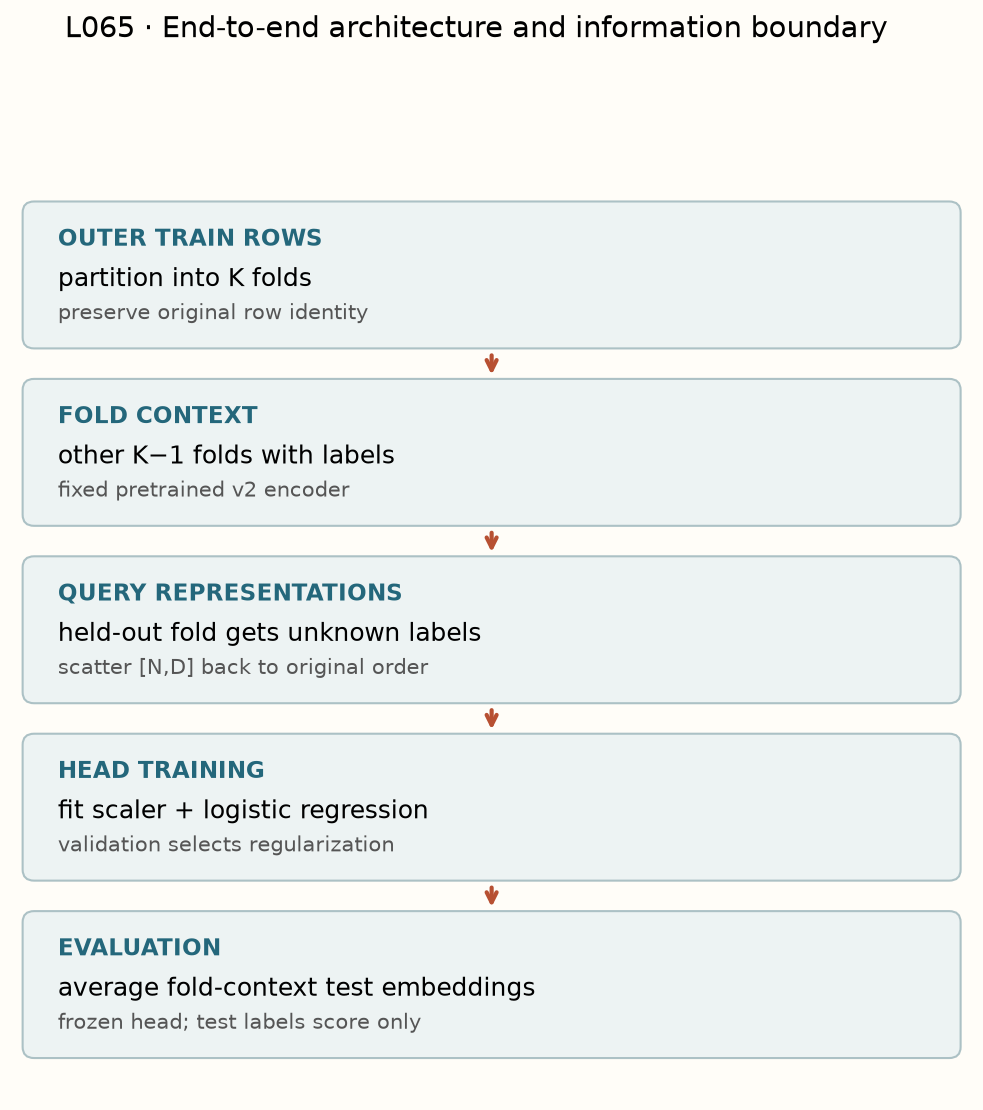</div>

*L065 architecture: worked computation; see adjacent explanation. Scroll wide figures horizontally on small screens.*

## Inspect separability without assuming causality

The lab measures a query-role linear head against native v2 predictions on diabetes, blood transfusion and phoneme with three seeds and identical outer rows. A small gap can show that the final hidden space supports a useful linear decision rule under this extraction protocol. It does not show that v2 internally reasons linearly, that those coordinates are causally meaningful, or that the head will retain its advantage under shift.

<div style="overflow-x:auto;max-width:100%">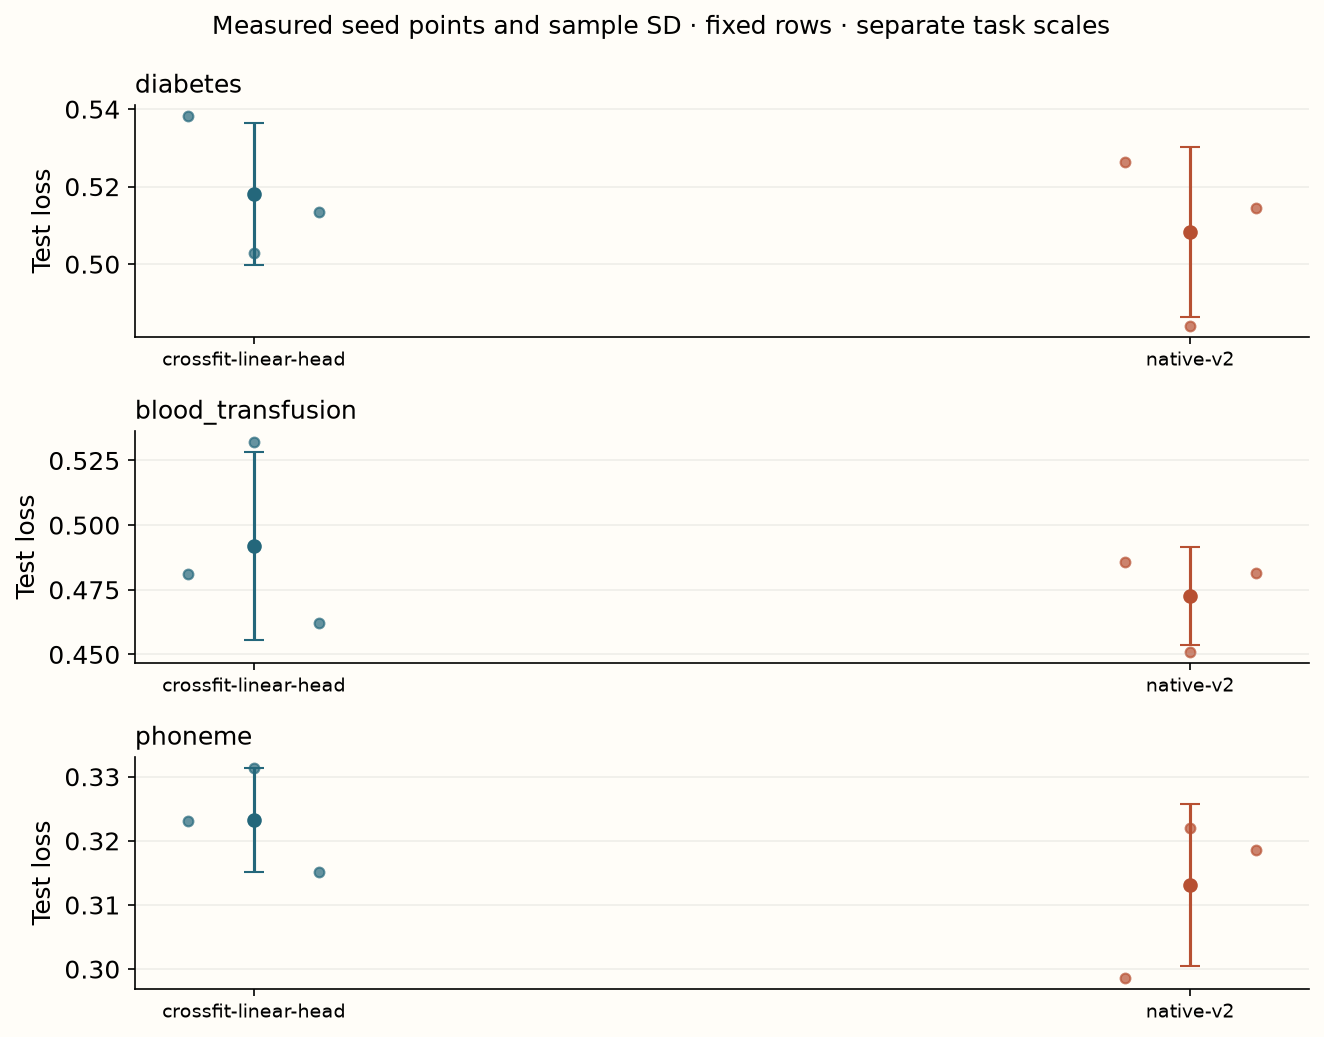</div>

*L065 results: author-reference measurements, separate from your kernel. Scroll wide figures horizontally on small screens.*

For an exploratory embedding visualization, fit PCA on training representations only, then transform validation/test vectors. PCA chooses directions of maximum variance; the first two components need not preserve the directions important for classification. Keep the projection and its fitting population fixed when comparing label-role interventions, or the changing display can conceal the effect you meant to inspect.

## Exit: prove the information boundary

Submit original row IDs, fold membership, embedding shapes, head selection results and native-versus-head test losses. Demonstrate that changing a held-out row's target does not change its query-role embedding when context is fixed. Then deliberately build an own-label context representation on a tiny fixture and explain why its apparent separability is misleading.

For the relational bridge, ask the same question of a row encoder: which related labels were available when this row representation was built? Point-in-time correctness must hold inside representation construction, not only in the final train/test split. A classifier cannot undo leaked information that an encoder has already placed in its inputs.

## Reproduction contract and task support

The visible code below implements the named operator or reduced architecture. The full pretrained model is a separately pinned reference path. Real public-table experiments use Tier A data; synthetic coin/SCM/shift tasks are Tier C mechanism isolation. Seeds, row identities, recipe budgets, versions and source/checkpoint hashes are available in the linked contract and evidence. Numerical agreement with a local operator is not a paper-table reproduction.

In [ ]:
# PROVIDED — environment, peripheral data/metric utilities
import os, sys, math, copy, re, json, hashlib, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch import nn
from scipy.stats import rankdata, friedmanchisquare, studentized_range, t
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.model_selection import StratifiedKFold
from threadpoolctl import threadpool_limits
from IPython.display import display
for directory in [Path.cwd(), Path.cwd()/'labs', Path.cwd().parent]:
    if (directory/'relkit').is_dir():
        ROOT=directory.resolve(); sys.path.insert(0,str(ROOT)); break
else:
    raise RuntimeError('Run the Colab bootstrap or start in the course repository')
torch.set_num_threads(1)
from relkit.foundation_benchmark import random_task, encode_train
print('CPU mechanism track; official checkpoint reruns use an isolated subprocess after EXIT.')

In [ ]:
# PROVIDED — context_mask; inspect the live function calls
def context_mask(n_context, n_query):
    """Boolean allow-mask: every row reads context; no row reads a query key."""
    if n_context < 1 or n_query < 1:
        raise ValueError('A nonempty context and query are required')
    mask = torch.zeros(n_context + n_query, n_context + n_query, dtype=torch.bool)
    mask[:, :n_context] = True
    return mask

In [ ]:
# PROVIDED — attention; inspect the live function calls
def attention(q, k, v, allowed=None):
    """Scaled dot-product attention; True means allowed (PyTorch SDPA convention)."""
    scores = q @ k.transpose(-1, -2) / math.sqrt(q.shape[-1])
    if allowed is not None:
        if not allowed.any(dim=-1).all():
            raise ValueError('Each query needs an allowed key')
        scores = scores.masked_fill(~allowed, float('-inf'))
    return scores.softmax(-1) @ v

In [ ]:
# PROVIDED — AttentionBlock; inspect the live function calls
class AttentionBlock(nn.Module):
    """Pre-normalized multihead attention plus residual feed-forward block."""
    def __init__(self, width, heads):
        super().__init__()
        if width % heads:
            raise ValueError('Width must be divisible by heads')
        self.heads = heads
        self.norm1, self.norm2 = nn.LayerNorm(width), nn.LayerNorm(width)
        self.qkv, self.out = nn.Linear(width, 3*width), nn.Linear(width, width)
        self.ff = nn.Sequential(nn.Linear(width, 2*width), nn.GELU(), nn.Linear(2*width, width))

    def forward(self, x, allowed=None):
        b, n, d = x.shape
        q, k, v = [a.reshape(b,n,self.heads,d//self.heads).transpose(1,2)
                   for a in self.qkv(self.norm1(x)).chunk(3,-1)]
        h = attention(q,k,v,allowed).transpose(1,2).reshape(b,n,d)
        x = x + self.out(h)
        return x + self.ff(self.norm2(x))

In [ ]:
# PROVIDED — RowPFN; inspect the live function calls
class RowPFN(nn.Module):
    """Reduced row-token PFN. Labels are embedded only for context rows.

    Shapes: context [B,C,F], query [B,Q,F], labels [B,C], logits [B,Q,2].
    No positions: simultaneous context row/label permutation leaves predictions fixed.
    """
    def __init__(self, features, width=32, heads=4, layers=2):
        super().__init__()
        self.x_encoder = nn.Linear(features,width)
        self.y_encoder = nn.Embedding(3,width)  # 0,1 plus an explicit unknown symbol
        self.blocks = nn.ModuleList([AttentionBlock(width,heads) for _ in range(layers)])
        self.head = nn.Sequential(nn.LayerNorm(width),nn.Linear(width,2))

    def embeddings(self, context, labels, query):
        c, q = context.shape[1], query.shape[1]
        h = self.x_encoder(torch.cat([context,query],1))
        unknown = torch.full((len(context),q),2,dtype=torch.long,device=context.device)
        h = h + self.y_encoder(torch.cat([labels.long(),unknown],1))
        allow = context_mask(c,q).to(context.device)
        for block in self.blocks:
            h = block(h,allow)
        return h[:,c:]

    def forward(self, context, labels, query):
        return self.head(self.embeddings(context,labels,query))

## TODO 1 · crossfit_embeddings

**Goal:** Extract each fold as queries against other-fold context; preserve row order and reject a one-fold design.

**Why it matters:** a wrong implementation can produce a plausible-looking experiment while violating this lesson's prediction contract. Before coding, name one input that should fail or one intervention that should leave the result unchanged.

**Hint boundary:** reason from the worked example and the function contract; the CHECK verifies behavior, not a required code layout.

In [ ]:
# TODO 1 — crossfit_embeddings
def crossfit_embeddings(x, y, fold_ids, embed):
    raise NotImplementedError("Implement the stated operation")

In [ ]:
# CHECK 1 — crossfit_embeddings
calls=[]
def diagnostic_embed(cx,cy,qx):
    calls.append((set(cx[:,0]),set(qx[:,0])));return qx*2
x=np.arange(12.).reshape(6,2);y=np.arange(6)%2;folds=np.array([0,1,0,1,0,1])
h=crossfit_embeddings(x,y,folds,diagnostic_embed)
np.testing.assert_array_equal(h,x*2)
assert all(not a&b for a,b in calls), 'A query entered its own labeled context'

print("PASS: crossfit_embeddings")

## Run your live implementation

Predict the outcome before execution. This cell calls the functions you just wrote. Changing a TODO must change the corresponding computation or make a CHECK fail. The text printed with the result identifies whether this is a small training run, a mechanism test or a reanalysis of committed measurements.

In [ ]:
# PROVIDED — experiment driven by your live functions
raw,y,reg,audit=random_task('diabetes',cap=150,seed=65);x=encode_train(raw)
scale=StandardScaler().fit(x['train']);z={s:scale.transform(a).astype('float32') for s,a in x.items()}
torch.manual_seed(65);model=RowPFN(z['train'].shape[1],width=16,heads=2).eval()
def embed(cx,cy,qx):
    with torch.no_grad():return model.embeddings(torch.tensor(cx)[None],torch.tensor(cy)[None],torch.tensor(qx)[None])[0].numpy()
folds=np.arange(len(y['train']))%3
train_h=crossfit_embeddings(z['train'],y['train'],folds,embed)
head=make_pipeline(StandardScaler(),LogisticRegression(max_iter=1000)).fit(train_h,y['train'])
test_h=embed(z['train'],y['train'],z['test']);p=head.predict_proba(test_h)
trial={'embedding_shape':list(train_h.shape),'test_log_loss':float(log_loss(y['test'],p)),
       'scope':'random-weight encoder diagnostic; actual pretrained v2 evidence is separate'};print(trial)

## Audit author-reference evidence

Inspect the measured results below independently of your smoke experiment. A fresh smoke may use a smaller budget. Preserve the protocol difference rather than forcing numerical agreement with a different run. The committed prediction arrays let you reconstruct scores without downloading pretrained weights.

In [ ]:
# PROVIDED — readable evidence, never impersonating current-kernel training
author=json.loads((ROOT/'_verify_l065_results.json').read_text())
print('AUTHOR REFERENCE:',author.get('scope',author.get('note','Declared checkpoint experiment')))
print('Evidence verdict:',author.get('verdict'))
rows=author.get('records',author.get('summary',[]))
if isinstance(rows,list) and rows:
    display(pd.DataFrame(rows).drop(columns=['predictions','targets','history','context_ids','task_losses'],errors='ignore').head(24))
if 65 in [60,70]:
    for regime,summary in author['summary'].items():
        print(regime,summary['mean_ranks'],'Friedman p=',summary['friedman_p'],'CD=',summary['nemenyi_cd'])

## EXIT TICKET · submit an executable argument

Provide your code output plus a 30–100 word verdict: which implementation ran, what information it could use, what evidence supports the result, and which paper claim remains untested. Include an unexpected or failed case and a next discriminating experiment. The length check below only enforces an attempt; the tutor grades your reasoning. Do not infer personal mastery from a green code cell.

In [ ]:
# TODO — written verdict; paste the resulting artifact and explanation to the tutor
verdict=''
assert len(verdict.split())>=30, 'Write a defensible verdict; a passing code cell is not the explanation'
ticket={'lesson':65,'checks':'passed in this kernel','trial':trial,'verdict':verdict,
        'paper_reproduction':'NOT_ESTABLISHED','author_reference':'_verify_l065_results.json'}
folder=ROOT/'data/cache/foundation';folder.mkdir(parents=True,exist_ok=True)
path=folder/'student-l065-exit.json'
path.write_text(json.dumps(ticket,indent=2,default=lambda x:x.item() if hasattr(x,'item') else x.tolist(),allow_nan=False)+'\n')
print('EXIT artifact:',path)

## NEXT STEP · reproduce or scale the declared track

Read [the exact reproduction contract](l065-reproduction.md) before increasing resources. The gate below invokes the shared runner in a subprocess; historical versions are installed into isolated package directories so v1 and v2 cannot silently replace one another. It may download the pinned checkpoint. Larger runs remain INCOMPARABLE wherever material paper-protocol gaps remain. A full paper preset deliberately fails until the original protocol is implemented.

For unattended CPU execution: `modal run --detach modal/foundation_repro.py --lesson 65 --preset closer`. This is a supplied operator, not evidence that a cloud job was run.

In [ ]:
# PROVIDED — explicit post-EXIT gate (OFF by default)
RUN_PAPER_REPRO=False
if RUN_PAPER_REPRO:
    import subprocess
    subprocess.run([sys.executable,str(ROOT/'_run_foundation.py'),'--lesson','65',
                    '--preset','closer','--output',str(ROOT/'data/cache/foundation/l065-closer.json')],check=True)
else:
    print('Scale-up NOT_RUN in this kernel. See the protocol ledger before enabling.')